In [27]:
import cv2
import numpy as np
import os
from google.colab import drive

In [28]:
# Mount Google Drive
drive.mount('/content/drive')


def load_and_preprocess_image(image_path):
    """
    Membaca citra, mengonversi ke grayscale,
    dan menghitung distribusi probabilitas histogram.
    """

    # Baca citra dalam format grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise FileNotFoundError(
            f"Gambar tidak ditemukan atau tidak dapat dibaca: {image_path}"
        )

    # Hitung histogram (frekuensi tiap intensitas 0-255)
    hist, _ = np.histogram(
        img.ravel(),
        bins=256,
        range=(0, 256)
    )

    # Normalisasi histogram menjadi distribusi probabilitas (p_i)
    total_pixels = img.size
    prob = hist / total_pixels

    return img, prob


# Path dataset di Google Drive
dataset_path = "/content/drive/MyDrive/smt 7/swarm/baru"


# Ambil semua file gambar dari folder
image_files = []

for filename in os.listdir(dataset_path):
    if filename.lower().endswith((
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp",
        ".tif",
        ".tiff"
    )):
        image_files.append(os.path.join(dataset_path, filename))


print(f"Jumlah gambar ditemukan: {len(image_files)}")


# Contoh membaca gambar pertama
if len(image_files) > 0:
    image_path = image_files[0]

    img, prob = load_and_preprocess_image(image_path)

    print(f"File: {image_path}")
    print(f"Ukuran gambar: {img.shape}")
    print(f"Jumlah pixel: {img.size}")
    print(f"Jumlah probabilitas histogram: {len(prob)}")
    print(f"Total probabilitas: {prob.sum()}")
else:
    print("Tidak ada gambar yang ditemukan di folder dataset.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Jumlah gambar ditemukan: 8
File: /content/drive/MyDrive/smt 7/swarm/baru/denpasar.jpg
Ukuran gambar: (646, 618)
Jumlah pixel: 399228
Jumlah probabilitas histogram: 256
Total probabilitas: 1.0


In [29]:
def otsu_fitness(thresholds, prob):
    """
    Menghitung Otsu's Between-Class Variance untuk sekelompok threshold.
    Goal: Memaksimalkan nilai variance ini.
    """
    # Pastikan threshold integer dan terurut
    thresholds = np.sort(np.round(thresholds).astype(int))

    # Tambahkan batas awal (0) dan akhir (256) untuk membuat interval kelas
    bounds = np.concatenate(([0], thresholds, [256]))

    total_mean = np.sum(np.arange(256) * prob)
    between_class_var = 0.0

    for i in range(len(bounds) - 1):
        low, high = bounds[i], bounds[i+1]

        # Probabilitas kumulatif kelas (w_i)
        w_i = np.sum(prob[low:high])

        if w_i > 0:
            # Mean kelas (mu_i)
            mean_i = np.sum(np.arange(low, high) * prob[low:high]) / w_i
            # Varians antar kelas
            between_class_var += w_i * ((mean_i - total_mean) ** 2)

    return between_class_var

In [30]:
def kapur_fitness(thresholds, prob):
    """
    Menghitung Kapur's Entropy untuk sekelompok threshold.
    Goal: Memaksimalkan total entropi.
    """
    # Epsilon kecil untuk menghindari log(0)
    eps = 1e-10

    thresholds = np.sort(np.round(thresholds).astype(int))
    bounds = np.concatenate(([0], thresholds, [256]))

    total_entropy = 0.0

    for i in range(len(bounds) - 1):
        low, high = bounds[i], bounds[i+1]

        # Probabilitas kelas
        w_i = np.sum(prob[low:high])

        if w_i > 0:
            # Probabilitas ternormalisasi di dalam kelas
            p_normalized = prob[low:high] / w_i
            # Hitung Entropi Shannon untuk kelas ini
            entropy_i = -np.sum(p_normalized * np.log(p_normalized + eps))
            total_entropy += entropy_i

    return total_entropy

In [31]:
if __name__ == "__main__":
    # Ganti dengan path gambarmu
    IMAGE_PATH = "/content/drive/MyDrive/smt 7/swarm/baru/tambak.jpg"

    try:
        img, prob = load_and_preprocess_image(IMAGE_PATH)
        print("✅ Pra-pemrosesan berhasil!")
        print(f"Total Piksel Citra: {img.shape[0]}x{img.shape[1]} = {img.size}")

        # Contoh pengujian manual dengan 3 Threshold (K = 3)
        dummy_thresholds = [64, 128, 192]

        # Uji Fungsi Fitness Otsu & Kapur
        score_otsu = otsu_fitness(dummy_thresholds, prob)
        score_kapur = kapur_fitness(dummy_thresholds, prob)

        print("\n--- Hasil Evaluasi Fitness Dummy ---")
        print(f"Thresholds         : {dummy_thresholds}")
        print(f"Otsu Fitness Score : {score_otsu:.4f}")
        print(f"Kapur Fitness Score: {score_kapur:.4f}")

    except Exception as e:
        print(f"Error: {e}")

✅ Pra-pemrosesan berhasil!
Total Piksel Citra: 652x822 = 535944

--- Hasil Evaluasi Fitness Dummy ---
Thresholds         : [64, 128, 192]
Otsu Fitness Score : 761.2171
Kapur Fitness Score: 14.5172


In [32]:
class RemoraOptimizationAlgorithm:
    def __init__(self, num_remoras=30, num_thresholds=2, max_iter=100, fitness_func=None):
        """
        Inisialisasi Parameter ROA untuk Multilevel Thresholding.

        :param num_remoras: Jumlah populasi remora (N)
        :param num_thresholds: Jumlah titik potong/threshold (K)
        :param max_iter: Maksimum iterasi (T_max)
        :param fitness_func: Fungsi evaluasi fitness (otsu_fitness atau kapur_fitness)
        """
        self.N = num_remoras
        self.K = num_thresholds
        self.max_iter = max_iter
        self.fitness_func = fitness_func

        # Batas pencarian intensitas piksel grayscale [0, 255]
        self.lb = 0
        self.ub = 255

        # Struktur data populasi dan histori
        self.positions = None      # Matriks populasi remora [N, K]
        self.fitness = None        # Array nilai fitness [N]
        self.best_position = None # Posisi global terbaik (G_best)
        self.best_fitness = -np.inf # Skor fitness terbaik
        self.history_best_fitness = [] # Track konvergensi untuk grafik

    def _enforce_bounds_and_sort(self, position):
        """
        Memastikan threshold bernilai integer [0, 255]
        dan selalu terurut secara ascending (t1 < t2 < ... < tK).
        """
        # Clip posisi ke dalam rentang [0, 255] dan pembulatan ke integer
        pos = np.clip(np.round(position), self.lb, self.ub).astype(int)
        # Urutkan secara ascending
        pos = np.sort(pos)
        return pos

    def initialize_population(self, prob):
        self.positions = np.zeros((self.N, self.K), dtype=int)
        self.fitness = np.zeros(self.N)

        for i in range(self.N):
            random_pos = np.random.choice(np.arange(self.lb + 1, self.ub), size=self.K, replace=False)
            self.positions[i] = self._enforce_bounds_and_sort(random_pos)
            self.fitness[i] = self.fitness_func(self.positions[i], prob)

            if self.fitness[i] > self.best_fitness:
                self.best_fitness = self.fitness[i]
                self.best_position = self.positions[i].copy()

    def optimize(self, prob):
        """
        Prosedur utama iterasi Remora Optimization Algorithm (ROA).
        """
        self.initialize_population(prob)

        # Simpan posisi iterasi sebelumnya untuk mekanisme Experience Attack
        prev_positions = self.positions.copy()

        for t in range(1, self.max_iter + 1):
            # Parameter adaptif C (menurun secara linear dari 1 ke 0)
            C = 1 - (t / self.max_iter)

            for i in range(self.N):
                current_pos = self.positions[i].copy()
                new_pos = current_pos.copy()

                # -------------------------------------------------------------
                # 1. Pilihan Inang / Host Strategy (SFO vs WOA)
                # -------------------------------------------------------------
                # Memilih inang secara acak: 0 untuk Swordfish (SFO), 1 untuk Whale (WOA)
                host_type = np.random.randint(0, 2)

                if host_type == 0:
                    # Strategy 1: Free Travel / SFO (Eksplorasi Global)
                    rand_idx = np.random.randint(0, self.N)
                    X_rand = self.positions[rand_idx]

                    # Formula pembaruan posisi SFO
                    rand_vec = np.random.rand(self.K)
                    new_pos = self.best_position - (rand_vec * ((self.best_position + X_rand) / 2) - X_rand)

                else:
                    # Strategy 2: Bubble-net Attacking / WOA (Eksploitasi Lokal)
                    b = 1.0  # Konstanta bentuk spiral
                    a = -1 + t * (-1 / self.max_iter) # Parameter penurunan linier
                    l = (a - 1) * np.random.rand() + 1

                    # Formula pembaruan posisi spiral WOA
                    D = np.abs(self.best_position - current_pos)
                    new_pos = D * np.exp(b * l) * np.cos(2 * np.pi * l) + self.best_position

                # Perbaiki batas dan urutkan threshold
                new_pos = self._enforce_bounds_and_sort(new_pos)
                new_fitness = self.fitness_func(new_pos, prob)

                # -------------------------------------------------------------
                # 2. Experience Attack (Pengujian Sekitar Inang)
                # -------------------------------------------------------------
                # Remora melakukan langkah kecil berdasarkan langkah iterasi sebelumnya
                att_pos = new_pos + (new_pos - prev_positions[i]) * np.random.rand(self.K)
                att_pos = self._enforce_bounds_and_sort(att_pos)
                att_fitness = self.fitness_func(att_pos, prob)

                # Evaluasi apakah Experience Attack menemukan hasil lebih baik
                if att_fitness > new_fitness:
                    new_pos = att_pos
                    new_fitness = att_fitness

                # -------------------------------------------------------------
                # 3. Host Switching Mechanism
                # -------------------------------------------------------------
                # Jika hasil baru lebih baik dari posisi remora saat ini, perbarui posisi
                if new_fitness > self.fitness[i]:
                    self.positions[i] = new_pos
                    self.fitness[i] = new_fitness

                    # Perbarui Global Best jika menemukan skor tertinggi baru
                    if new_fitness > self.best_fitness:
                        self.best_fitness = new_fitness
                        self.best_position = new_pos.copy()

            # Simpan histori posisi untuk iterasi berikutnya
            prev_positions = self.positions.copy()
            self.history_best_fitness.append(self.best_fitness)

            # Log progress tiap 20 iterasi
            if t % 20 == 0 or t == self.max_iter:
                print(f"Iterasi [{t}/{self.max_iter}] - Best Fitness ({self.fitness_func.__name__}): {self.best_fitness:.4f} | Best Thresholds: {self.best_position}")

        return self.best_position, self.best_fitness, self.history_best_fitness

In [33]:
if __name__ == "__main__":
    # Import fungsi dari file Phase 1 (Dihapus karena fungsi sudah tersedia dalam scope notebook)
    # from phase1 import load_and_preprocess_image, otsu_fitness, kapur_fitness

    IMAGE_PATH = "/content/drive/MyDrive/smt 7/swarm/baru/tabanan.jpg" # Ganti dengan path gambarmu

    try:
        # Load & Preprocess
        img, prob = load_and_preprocess_image(IMAGE_PATH)
        print("✅ Data Citra Berhasil Dimuat.")

        # Eksekusi ROA dengan Otsu Fitness
        NUM_THRESHOLDS = 6  # Mencari K = 5 threshold
        print(f"\n--- Memulai Optimasi ROA (Multilevel Thresholding K={NUM_THRESHOLDS}) ---")

        roa = RemoraOptimizationAlgorithm(
            num_remoras=25,
            num_thresholds=NUM_THRESHOLDS,
            max_iter=100,
            fitness_func=otsu_fitness
        )

        best_thresholds, best_score, convergence_curve = roa.optimize(prob)

        print("\n🏆 HASIL OPTIMASI FINAL 🏆")
        print(f"Optimal Thresholds (T*) : {best_thresholds}")
        print(f"Max Otsu Fitness Score  : {best_score:.4f}")

    except FileNotFoundError as e:
        print(f"⚠️ {e}. Silakan ganti IMAGE_PATH ke file gambar yang valid.")
    except Exception as e:
        print(f"An error occurred: {e}")

✅ Data Citra Berhasil Dimuat.

--- Memulai Optimasi ROA (Multilevel Thresholding K=6) ---
Iterasi [20/100] - Best Fitness (otsu_fitness): 1693.3948 | Best Thresholds: [ 30  53  77 102 132 175]
Iterasi [40/100] - Best Fitness (otsu_fitness): 1693.3948 | Best Thresholds: [ 30  53  77 102 132 175]
Iterasi [60/100] - Best Fitness (otsu_fitness): 1693.3948 | Best Thresholds: [ 30  53  77 102 132 175]
Iterasi [80/100] - Best Fitness (otsu_fitness): 1693.3948 | Best Thresholds: [ 30  53  77 102 132 175]
Iterasi [100/100] - Best Fitness (otsu_fitness): 1693.3948 | Best Thresholds: [ 30  53  77 102 132 175]

🏆 HASIL OPTIMASI FINAL 🏆
Optimal Thresholds (T*) : [ 30  53  77 102 132 175]
Max Otsu Fitness Score  : 1693.3948


In [34]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

In [35]:
def apply_multilevel_threshold(img, thresholds):
    # Menentukan nilai representatif untuk tiap wilayah/level
    bounds = np.concatenate(([0], np.sort(thresholds), [255]))
    # Ambil nilai tengah interval sebagai nilai piksel baru
    level_values = [int((bounds[i] + bounds[i+1]) / 2) for i in range(len(bounds)-1)]

    # Kuantisasi piksel berdasarkan interval threshold
    indices = np.digitize(img, np.sort(thresholds))
    img_seg = np.array(level_values)[indices].astype(np.uint8)
    return img_seg

In [36]:
def calculate_fsim(img_orig, img_seg):
    """
    Menghitung Feature Similarity Index (FSIM) berbasis Phase Congruency & Gradient Magnitude.
    Sederhana: Menggunakan deviasi gradien Scharr/Sobel sebagai representasi fitur low-level.
    """
    # Hitung Gradien Magnitude menggunakan Sobel
    gx_orig = cv2.Sobel(img_orig, cv2.CV_64F, 1, 0, ksize=3)
    gy_orig = cv2.Sobel(img_orig, cv2.CV_64F, 0, 1, ksize=3)
    mag_orig = np.sqrt(gx_orig**2 + gy_orig**2)

    gx_seg = cv2.Sobel(img_seg, cv2.CV_64F, 1, 0, ksize=3)
    gy_seg = cv2.Sobel(img_seg, cv2.CV_64F, 0, 1, ksize=3)
    mag_seg = np.sqrt(gx_seg**2 + gy_seg**2)

    # Similarity dari gradien magnitude
    c2 = 160.0
    similarity = (2 * mag_orig * mag_seg + c2) / (mag_orig**2 + mag_seg**2 + c2)

    return np.mean(similarity)

def evaluate_segmentation_quality(img_orig, img_seg):
    """
    Menghitung metrik evaluasi kualitas segmentasi: PSNR, SSIM, dan FSIM.
    """
    # 1. Peak Signal-to-Noise Ratio (PSNR)
    psnr_value = psnr(img_orig, img_seg, data_range=255)

    # 2. Structural Similarity Index (SSIM)
    ssim_value = ssim(img_orig, img_seg, data_range=255)

    # 3. Feature Similarity Index (FSIM)
    fsim_value = calculate_fsim(img_orig, img_seg)

    return psnr_value, ssim_value, fsim_value

In [37]:
def clean_binary_mask(binary_mask):
    """
    Membersihkan bintik noise & menambal lubang pada mask biner.
    """
    # Kernel ukuran 5x5 piksel
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

    # 1. Opening: Menghilangkan bintik-bintik noise kecil di luar objek
    cleaned = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel, iterations=2)

    # 2. Closing: Menambal/menutup lubang-lubang kecil di dalam tubuh objek
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel, iterations=2)

    return cleaned

In [38]:
def plot_results(img_orig, img_seg, thresholds, convergence_curve, metrics):
    """
    Menampilkan citra asli vs segmentasi, histogram + garis threshold,
    dan kurva konvergensi fitness ROA.
    """
    psnr_val, ssim_val, fsim_val = metrics

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Hasil Segmentasi Citra Multilevel Thresholding (ROA)", fontsize=16, fontweight='bold')

    # 1. Citra Asli
    axes[0, 0].imshow(img_orig, cmap='gray')
    axes[0, 0].set_title("Citra Asli (Grayscale)")
    axes[0, 0].axis('off')

    # 2. Citra Tersegmentasi
    axes[0, 1].imshow(img_seg, cmap='gray')
    axes[0, 1].set_title(f"Hasil Segmentasi (K = {len(thresholds)})\nPSNR: {psnr_val:.2f} dB | SSIM: {ssim_val:.4f} | FSIM: {fsim_val:.4f}")
    axes[0, 1].axis('off')

    # 3. Histogram & Threshold Markers
    hist, bins = np.histogram(img_orig.ravel(), bins=256, range=(0, 256))
    axes[1, 0].plot(hist, color='black', alpha=0.7, label='Histogram')
    axes[1, 0].set_title("Histogram Intensitas & Posisi Threshold (T*)")
    axes[1, 0].set_xlabel("Intensitas Piksel (0-255)")
    axes[1, 0].set_ylabel("Frekuensi")

    colors = ['red', 'green', 'blue', 'orange', 'purple', 'magenta']
    for idx, t in enumerate(thresholds):
        color = colors[idx % len(colors)]
        axes[1, 0].axvline(x=t, color=color, linestyle='--', linewidth=2, label=f't_{idx+1} = {t}')
    axes[1, 0].legend(loc='upper right')
    axes[1, 0].grid(True, alpha=0.3)

    # 4. Kurva Konvergensi Fitness ROA
    axes[1, 1].plot(convergence_curve, color='crimson', linewidth=2, marker='o', markevery=max(1, len(convergence_curve)//10))
    axes[1, 1].set_title("Kurva Konvergensi Remora Optimization Algorithm (ROA)")
    axes[1, 1].set_xlabel("Iterasi")
    axes[1, 1].set_ylabel("Nilai Fitness (Otsu / Kapur)")
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

🚀 Memulai Proses Optimasi ROA...
Iterasi [20/100] - Best Fitness (otsu_fitness): 2460.2998 | Best Thresholds: [ 49  77 104 129 155 184]
Iterasi [40/100] - Best Fitness (otsu_fitness): 2460.2998 | Best Thresholds: [ 49  77 104 129 155 184]
Iterasi [60/100] - Best Fitness (otsu_fitness): 2460.2998 | Best Thresholds: [ 49  77 104 129 155 184]
Iterasi [80/100] - Best Fitness (otsu_fitness): 2460.2998 | Best Thresholds: [ 49  77 104 129 155 184]
Iterasi [100/100] - Best Fitness (otsu_fitness): 2460.2998 | Best Thresholds: [ 49  77 104 129 155 184]

📊 HASIL EVALUASI SEGMENTASI FINAL
Optimal Thresholds (T*) : [ 49  77 104 129 155 184]
Best Fitness Score      : 2460.2998
PSNR                    : 27.5856 dB
SSIM                    : 0.8717
FSIM                    : 0.7816


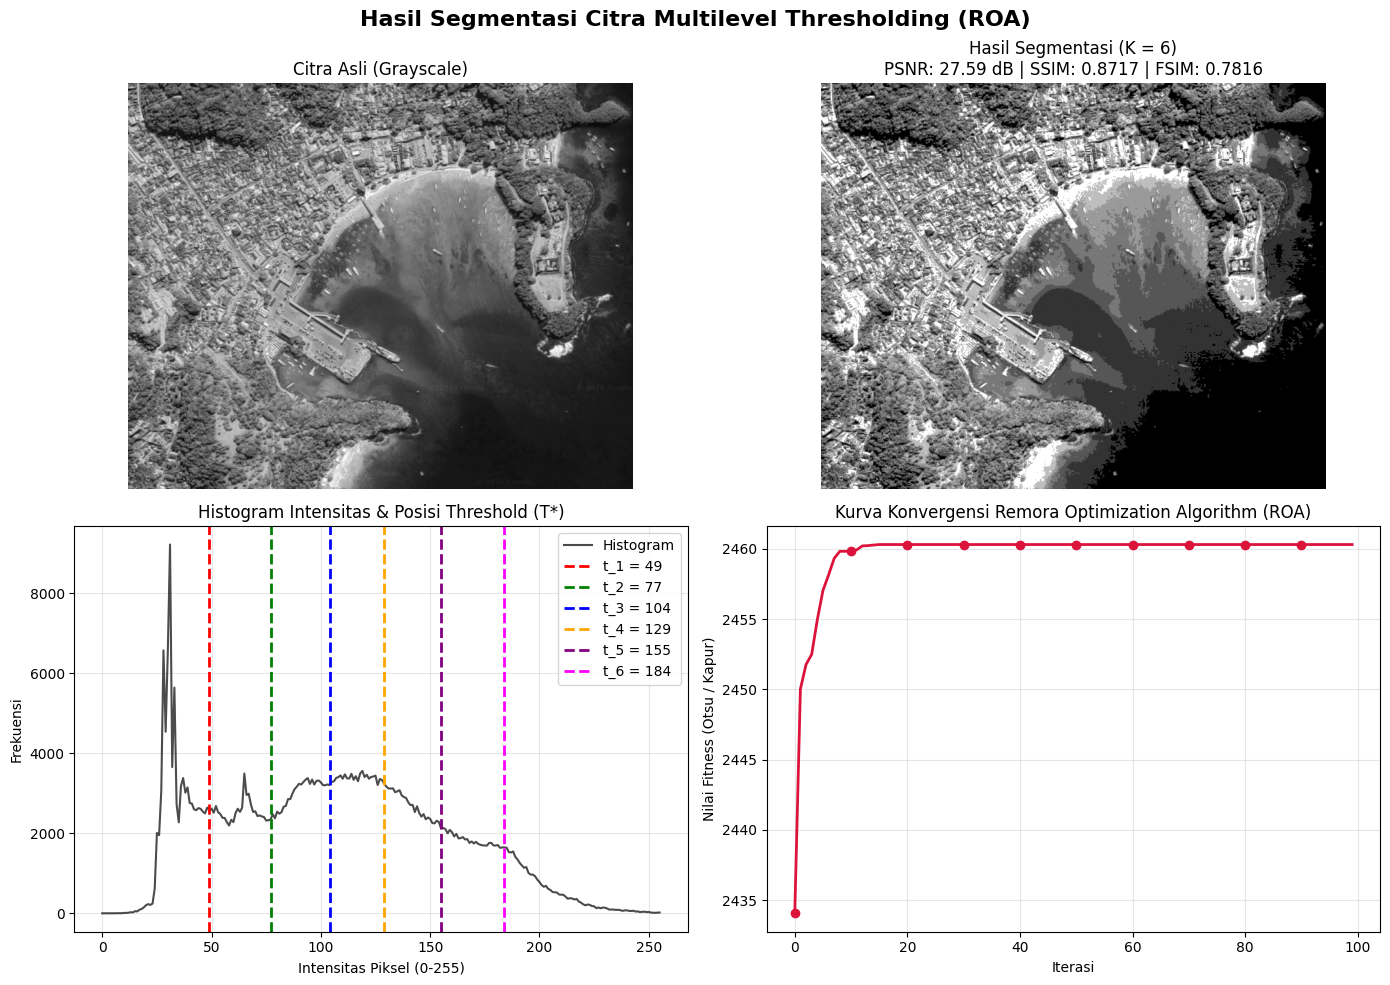

In [39]:
if __name__ == "__main__":
    # Import fungsi dari file Phase 1 (Dihapus karena fungsi sudah tersedia dalam scope notebook)
    # from phase1 import load_and_preprocess_image, otsu_fitness, kapur_fitness
    # from phase2 import RemoraOptimizationAlgorithm

    # Menggunakan path gambar yang valid dari Google Drive
    IMAGE_PATH = "/content/drive/MyDrive/smt 7/swarm/baru/padang_bai.jpg"  # Ganti dengan path gambarmu

    try:
        # Step 1: Load Data & Preprocessing (Phase 1)
        img_orig, prob = load_and_preprocess_image(IMAGE_PATH)

        # Step 2: Optimasi ROA (Phase 2)
        NUM_THRESHOLDS = 6
        MAX_ITER = 100

        print("🚀 Memulai Proses Optimasi ROA...")
        roa = RemoraOptimizationAlgorithm(
            num_remoras=30,
            num_thresholds=NUM_THRESHOLDS,
            max_iter=MAX_ITER,
            fitness_func=otsu_fitness
        )

        # 1. Cari 1 threshold optimal menggunakan ROA
        best_thresholds, best_score, convergence_curve = roa.optimize(prob)

        # 2. Buat Binary Mask biner murni
        raw_mask = apply_multilevel_threshold(img_orig, best_thresholds)

        # 3. Bersihkan noise pada mask
        img_segmented = apply_multilevel_threshold(img_orig, best_thresholds)

        # 4. Hitung metrik dan tampilkan plot hasil
        psnr_val, ssim_val, fsim_val = evaluate_segmentation_quality(img_orig, img_segmented)

        print("\n" + "="*50)
        print("📊 HASIL EVALUASI SEGMENTASI FINAL")
        print("="*50)
        print(f"Optimal Thresholds (T*) : {best_thresholds}")
        print(f"Best Fitness Score      : {best_score:.4f}")
        print(f"PSNR                    : {psnr_val:.4f} dB")
        print(f"SSIM                    : {ssim_val:.4f}")
        print(f"FSIM                    : {fsim_val:.4f}")
        print("="*50)

        # Step 5: Visualisasi Plot
        plot_results(
            img_orig,
            img_segmented,
            best_thresholds,
            convergence_curve,
            (psnr_val, ssim_val, fsim_val)
        )

    except FileNotFoundError as e:
        print(f"⚠️ {e}. Pastikan file citra tersedia di directory.")
    except Exception as e:
        print(f"An error occurred: {e}")